# Predicting subsurface eddy tilt from surface signatures

This workflow tests AE and CE independently. It reserves a final set of unseen eddies before any model, target formulation, hyperparameter, or feature-set selection. Training gives each eddy equal total weight so long-lived eddies do not dominate.

Two target formulations compete during grouped training-only cross-validation:

1. direct eastward and northward tilt components;
2. `log1p(TiltDis)` and the circular directional offset from the PV-gradient bearing.

The final test eddies are evaluated exactly once after all choices are fixed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt
import ml_subsurface_tools as ml

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
TEST_SIZE = 0.20
INNER_FOLDS = 5
REPEATED_SPLITS = 5

## 1. Load data and enforce a common vertical interval

Tilt is capped at the approximately 859 m model level. Only eddy-days with a vertical profile deeper than 850 m are retained, so every target represents the complete measured interval. Filtering occurs before the relatively expensive core-mean PV calculation.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
df_vert = tilt.load_vert(paths)

max_depth = (
    df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
    .max()
    .rename(columns={"Depth": "max_profile_depth"})
)
df_eddies = df_eddies.merge(max_depth, on=["Eddy", "Day"], how="inner")
df_eddies = df_eddies[df_eddies["max_profile_depth"] > 850].copy()
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

print(f"Rows reaching the full depth: {len(df_eddies):,}")
print(f"Eddies reaching the full depth: {df_eddies['Eddy'].nunique():,}")

Rows reaching the full depth: 88,199
Eddies reaching the full depth: 2,793


## 2. Engineer predictors and audit target coverage

The canonical predictors are:

```text
beta, h, Omega, Rc, AR, norm_time
prop_east_km_day, prop_north_km_day
ellipse_major_cos2, ellipse_major_sin2
Rc_tendency_km_day, Omega_tendency_day
PV_grad_mag, PV_grad_east, PV_grad_north
```

Only `beta` is used from the correlated latitude/Coriolis group; `lat` and `f` are excluded. `Omega` is used and `w` is excluded. Ellipse orientation uses `sin(2θ)` and `cos(2θ)` because an ellipse axis is 180° periodic. Dynamic predictors are daily differences within each eddy. Missing first-day dynamics are imputed inside each training fold.

In [3]:
display(ml.target_availability_summary(df_eddies))

model_df = ml.prepare_modelling_table(df_eddies)
polarity_data = {cyc: model_df[model_df["Cyc"] == cyc].copy() for cyc in ("AE", "CE")}

display(pd.DataFrame({
    cyc: {"rows": len(part), "eddies": part["Eddy"].nunique()}
    for cyc, part in polarity_data.items()
}).T)
display(pd.Series(ml.FEATURES, name="model_feature").to_frame())

,rows,valid_tilt_rows,valid_fraction,eddies,eddies_with_tilt
group,,,,,
All,88199,79390,0.900124,2793,2745
AE,42658,38935,0.912724,1319,1284
CE,45541,40455,0.888320,1474,1461


,rows,eddies
AE,38935,1284
CE,40455,1461


,model_feature
0,beta
1,h
2,Omega
3,Rc
4,AR
5,norm_time
6,prop_east_km_day
7,prop_north_km_day
8,ellipse_major_cos2
9,ellipse_major_sin2


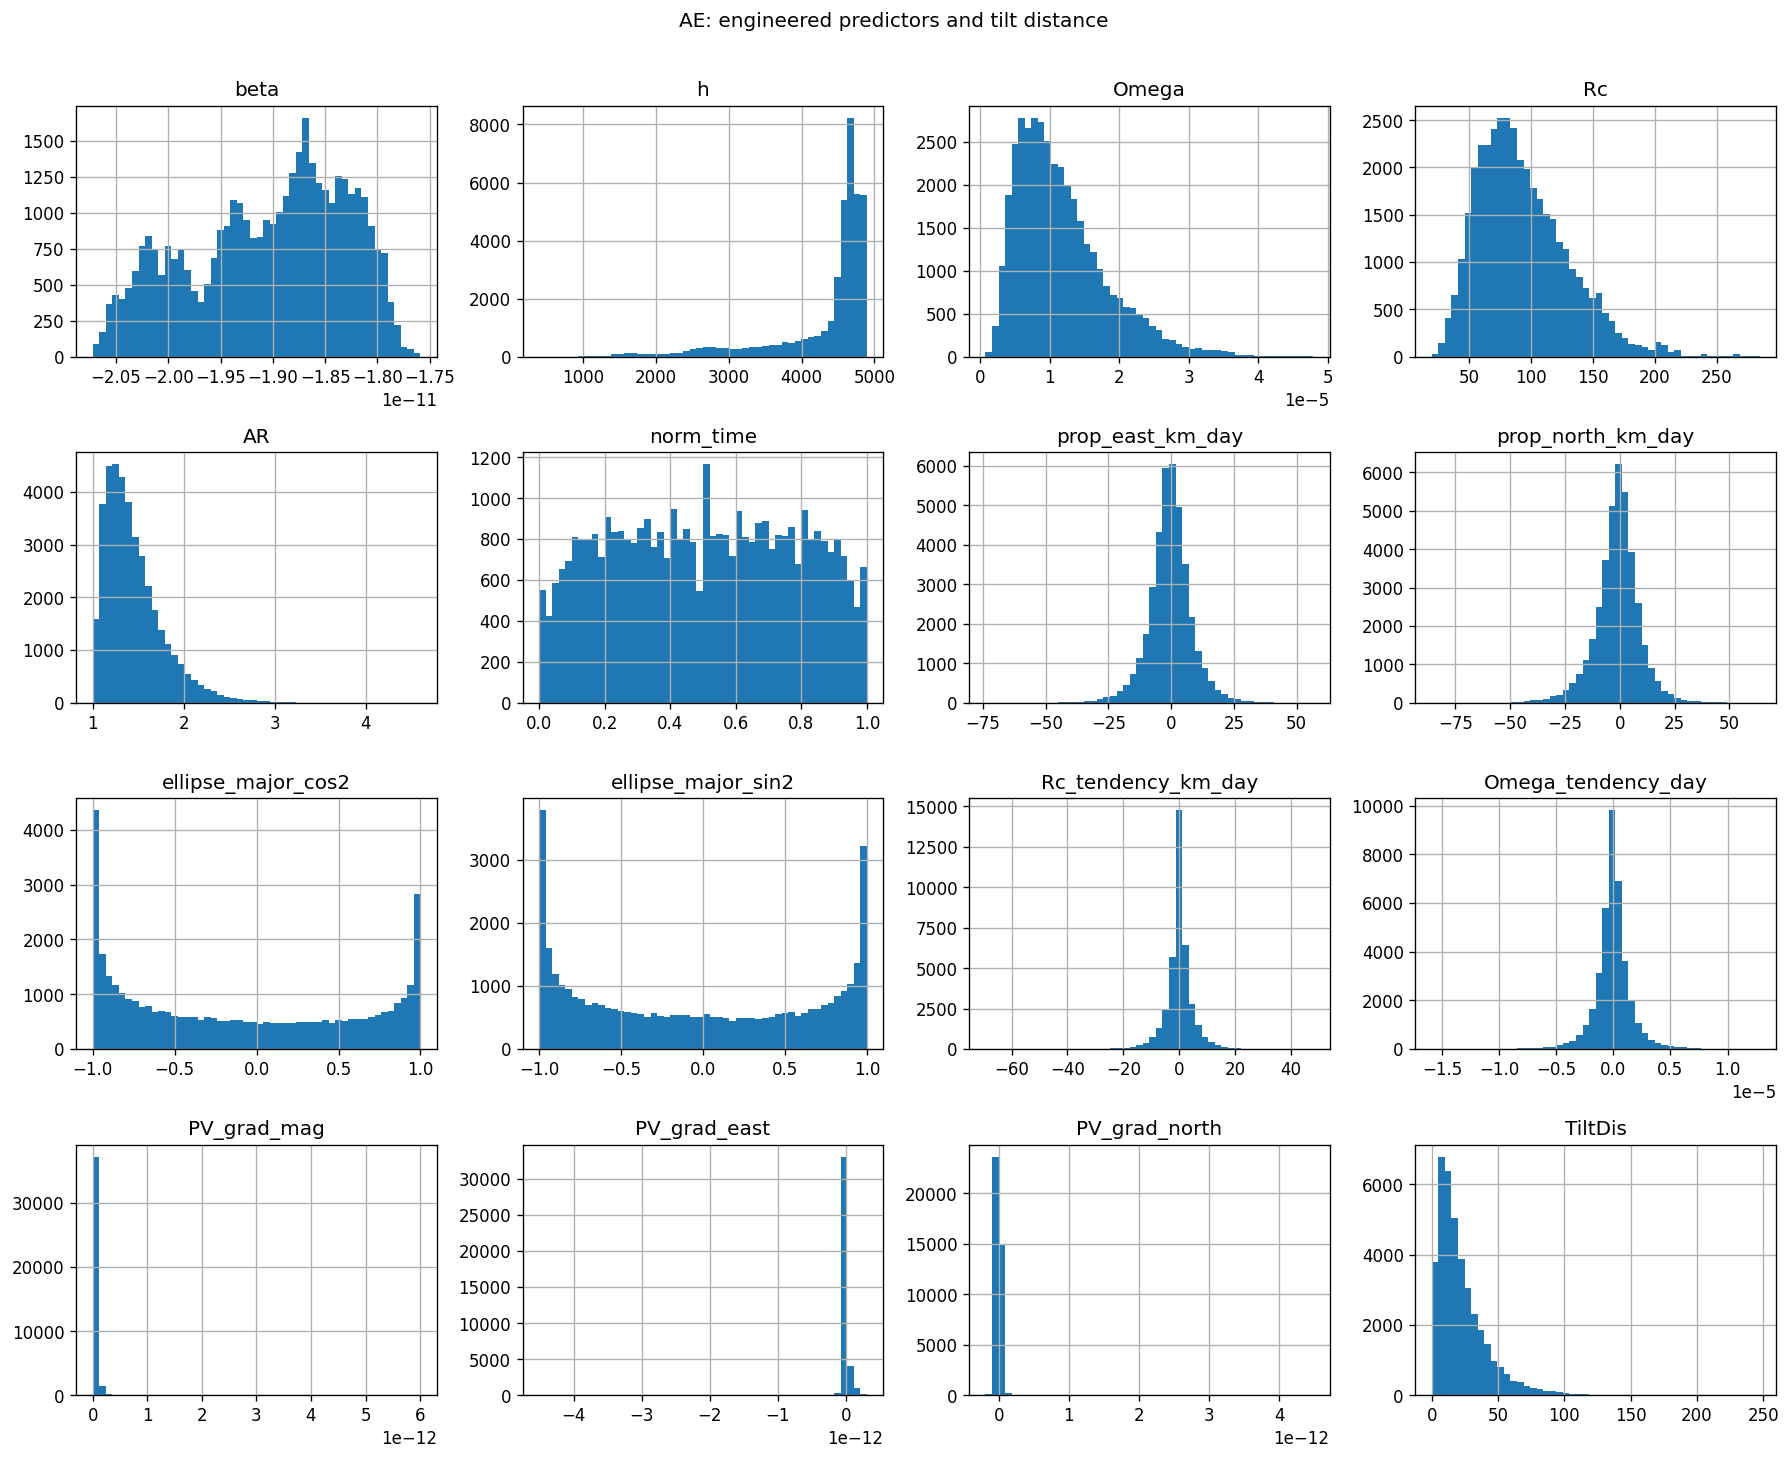

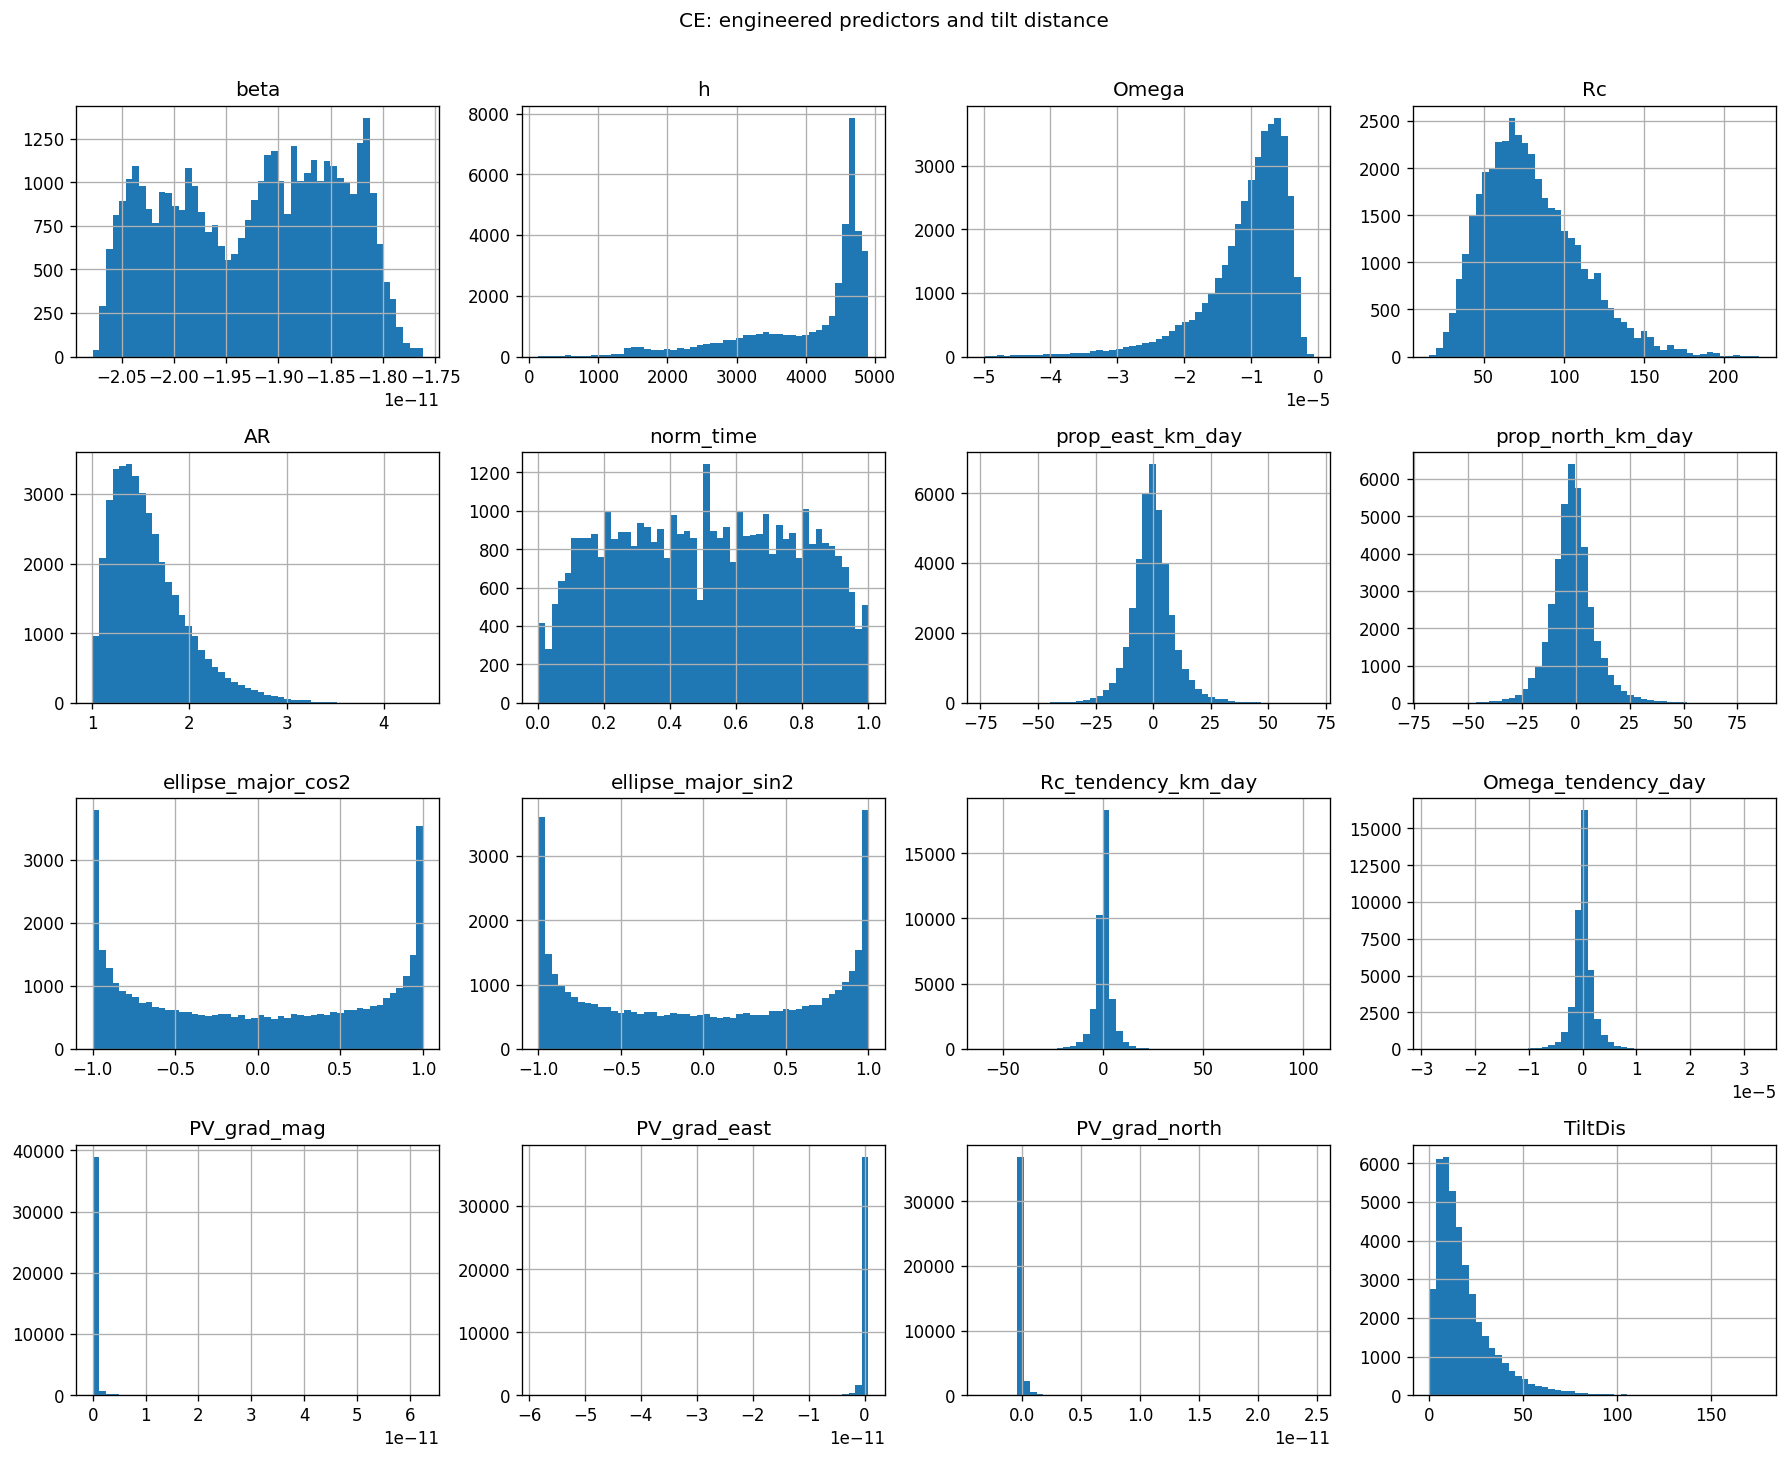

In [4]:
for cyc, part in polarity_data.items():
    part[ml.FEATURES + ["TiltDis"]].hist(bins=50, figsize=(15, 12))
    plt.suptitle(f"{cyc}: engineered predictors and tilt distance", y=1.01)
    plt.tight_layout()

## 3. Reserve untouched final-test eddies

AE and CE are split independently. Every observation from an eddy stays on one side of the split. Nothing below the next model-selection section may use the final test observations until Part 7.

In [5]:
splits = {
    cyc: ml.grouped_train_test_split(part, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    for cyc, part in polarity_data.items()
}

summary = []
for cyc, split in splits.items():
    assert set(split.groups_train).isdisjoint(set(split.groups_test))
    summary.append({
        "Cyc": cyc, "training rows": len(split.train), "test rows": len(split.test),
        "training eddies": split.groups_train.nunique(),
        "untouched test eddies": split.groups_test.nunique(),
    })
pd.DataFrame(summary).set_index("Cyc")

,training rows,test rows,training eddies,untouched test eddies
Cyc,,,,
AE,31407,7528,1027,257
CE,31964,8491,1168,293


## 4. Training-only grouped model and hyperparameter selection

Five-fold grouped CV compares Ridge regularisation, four restrained gradient-boosting configurations, and both target formulations. Each fold includes a mean-vector and PV-direction baseline. Selection uses equal-eddy-weighted vector MAE. This is the most computationally intensive section.

In [6]:
candidates = ml.default_candidates()
tuning = {}
selected = {}

for cyc, split in splits.items():
    print(f"Tuning {cyc}...")
    tuning[cyc] = ml.tune_candidates_grouped(
        split.train, candidates=candidates, n_splits=INNER_FOLDS, random_state=RANDOM_STATE
    )
    selected[cyc] = ml.best_candidate(tuning[cyc], candidates)
    print(cyc, selected[cyc])
    display(ml.summarise_tuning(tuning[cyc]).head(12).round(3))

Tuning AE...
AE {'family': 'Gradient boosting', 'target_mode': 'cartesian', 'params': {'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 1.0}}


,,,,vector_MAE_mean,vector_MAE_std,eddy_vector_MAE_mean,distance_MAE_mean,angular_error_median,within_30deg_mean
candidate_id,family,target_mode,params,,,,,,
8,Gradient boosting,cartesian,"{'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",20.279,1.257,26.485,13.392,44.172,0.368
3,Ridge,cartesian,{'alpha': 100.0},20.575,1.165,26.550,13.758,45.998,0.353
2,Ridge,cartesian,{'alpha': 10.0},20.581,1.166,26.556,13.754,46.010,0.353
1,Ridge,cartesian,{'alpha': 1.0},20.582,1.166,26.556,13.754,46.012,0.353
0,Ridge,cartesian,{'alpha': 0.1},20.582,1.166,26.556,13.754,46.012,0.353
10,Gradient boosting,cartesian,"{'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 10.0}",20.520,1.365,26.792,13.207,44.550,0.367
9,Gradient boosting,cartesian,"{'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",20.670,1.260,27.051,13.140,44.802,0.366
11,Gradient boosting,cartesian,"{'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 1.0}",20.761,1.435,27.083,13.161,45.851,0.359
Mean-vector baseline,Mean-vector baseline,baseline,{},21.583,1.123,27.731,15.316,54.037,0.285


Tuning CE...
CE {'family': 'Gradient boosting', 'target_mode': 'cartesian', 'params': {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 10.0}}


,,,,vector_MAE_mean,vector_MAE_std,eddy_vector_MAE_mean,distance_MAE_mean,angular_error_median,within_30deg_mean
candidate_id,family,target_mode,params,,,,,,
10,Gradient boosting,cartesian,"{'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 10.0}",16.739,0.661,20.442,11.196,48.660,0.349
8,Gradient boosting,cartesian,"{'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",16.731,0.641,20.479,11.309,47.589,0.350
11,Gradient boosting,cartesian,"{'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 1.0}",16.957,0.568,20.630,10.960,48.279,0.348
9,Gradient boosting,cartesian,"{'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",16.941,0.614,20.649,10.951,48.270,0.355
2,Ridge,cartesian,{'alpha': 10.0},17.351,0.627,20.925,12.280,52.224,0.325
1,Ridge,cartesian,{'alpha': 1.0},17.351,0.627,20.925,12.279,52.203,0.325
0,Ridge,cartesian,{'alpha': 0.1},17.351,0.627,20.925,12.279,52.201,0.325
3,Ridge,cartesian,{'alpha': 100.0},17.351,0.629,20.925,12.290,52.331,0.324
Mean-vector baseline,Mean-vector baseline,baseline,{},18.003,0.807,21.749,14.066,63.627,0.271


## 5. Training-only feature ablation

Using each polarity's selected model configuration, grouped CV tests whether PV magnitude, PV components, all PV terms, the added dynamic features, and `AR` improve generalisation. The final test set remains untouched.

AE selected feature set: full_PV_vector


,eddy_vector_MAE,fold_SD,distance_MAE,angular_error
feature_set,,,,
full_PV_vector,26.485,1.674,13.392,44.172
PV_components_only,26.517,1.653,13.358,44.309
full_without_AR,26.554,1.631,13.422,44.813
PV_magnitude_only,26.575,1.623,13.501,44.455
surface_without_PV,26.609,1.599,13.465,44.526
full_without_dynamics,27.507,1.608,14.003,52.440


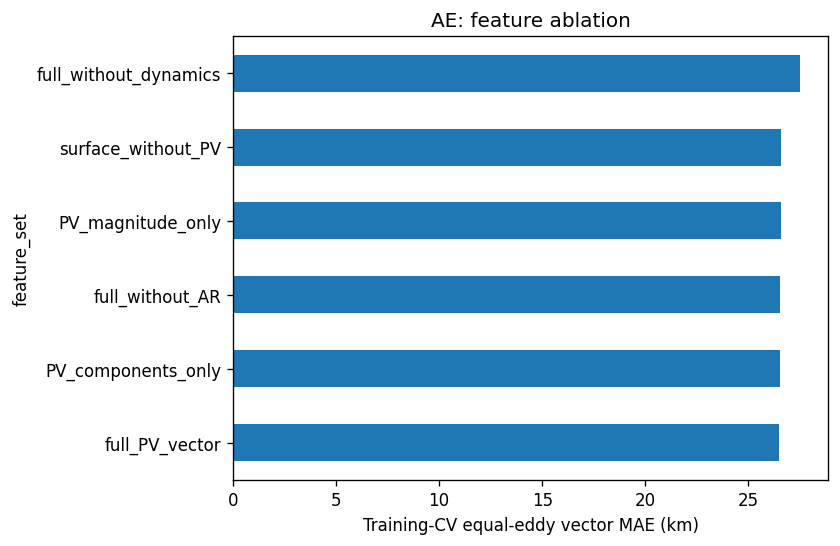

CE selected feature set: full_PV_vector


,eddy_vector_MAE,fold_SD,distance_MAE,angular_error
feature_set,,,,
full_PV_vector,20.442,1.049,11.196,48.660
full_without_AR,20.510,0.992,11.257,48.499
PV_components_only,20.520,1.066,11.172,47.141
PV_magnitude_only,20.682,0.892,11.332,50.185
surface_without_PV,20.796,0.924,11.429,51.674
full_without_dynamics,21.326,1.111,11.530,55.137


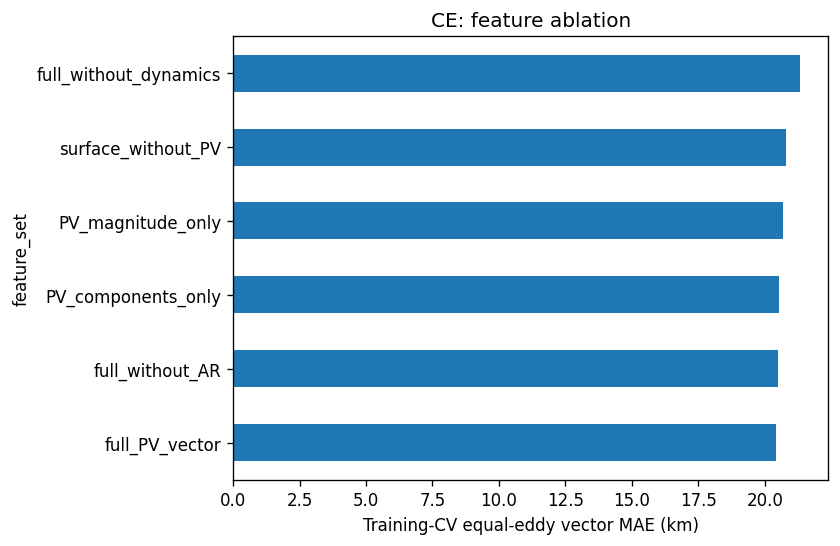

In [7]:
ablation = {}
chosen_features = {}
for cyc, split in splits.items():
    ablation[cyc] = ml.feature_ablation_cv(
        split.train, selected[cyc], n_splits=INNER_FOLDS, random_state=RANDOM_STATE
    )
    ablation_summary = (
        ablation[cyc].groupby("feature_set")
        .agg(eddy_vector_MAE=("eddy_weighted_vector_MAE_km", "mean"),
             fold_SD=("eddy_weighted_vector_MAE_km", "std"),
             distance_MAE=("distance_MAE_km", "mean"),
             angular_error=("median_angular_error_deg", "median"))
        .sort_values("eddy_vector_MAE")
    )
    best_set = ablation_summary.index[0]
    chosen_features[cyc] = ml.FEATURE_SETS[best_set]
    print(f"{cyc} selected feature set: {best_set}")
    display(ablation_summary.round(3))
    ablation_summary["eddy_vector_MAE"].sort_values().plot.barh(title=f"{cyc}: feature ablation")
    plt.xlabel("Training-CV equal-eddy vector MAE (km)")
    plt.show()

## 6. Repeated grouped validation inside the training population

Five additional grouped holdouts test sensitivity to which training eddies are selected. Baselines are recomputed inside every repeat. These repeats use only the original training population.

In [8]:
repeated = {}
for cyc, split in splits.items():
    repeated[cyc] = ml.repeated_grouped_validation(
        split.train, selected[cyc], features=chosen_features[cyc],
        n_repeats=REPEATED_SPLITS, random_state=100,
    )
    display(repeated[cyc].groupby("model").agg(
        vector_MAE=("eddy_weighted_vector_MAE_km", "mean"),
        split_SD=("eddy_weighted_vector_MAE_km", "std"),
        distance_MAE=("eddy_weighted_distance_MAE_km", "mean"),
        angular_error=("median_angular_error_deg", "median"),
    ).sort_values("vector_MAE").round(3))

,vector_MAE,split_SD,distance_MAE,angular_error
model,,,,
Selected model,26.700,0.802,17.968,46.790
Mean-vector baseline,27.947,1.296,20.832,57.169
PV-direction baseline,35.713,1.161,16.552,96.108


,vector_MAE,split_SD,distance_MAE,angular_error
model,,,,
Selected model,20.533,0.421,13.610,48.610
Mean-vector baseline,21.248,0.535,16.816,62.988
PV-direction baseline,24.801,0.398,12.769,63.817


## 7. One final evaluation on untouched eddies

All model and feature choices are now fixed. Each selected model is fitted to all training eddies and evaluated once against its untouched final-test eddies. Both row-weighted and equal-eddy-weighted errors are reported.

AE: {'family': 'Gradient boosting', 'target_mode': 'cartesian', 'params': {'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 1.0}}
Features: ['beta', 'h', 'Omega', 'Rc', 'AR', 'norm_time', 'prop_east_km_day', 'prop_north_km_day', 'ellipse_major_cos2', 'ellipse_major_sin2', 'Rc_tendency_km_day', 'Omega_tendency_day', 'PV_grad_mag', 'PV_grad_east', 'PV_grad_north']


,vector_MAE_km,vector_RMSE_km,distance_MAE_km,distance_RMSE_km,east_R2,north_R2,median_angular_error_deg,within_30deg_fraction,eddy_weighted_vector_MAE_km,eddy_weighted_distance_MAE_km
model,,,,,,,,,,
Selected model,21.631,28.127,14.477,21.801,0.113,0.079,46.237,0.368,28.282,19.821
Mean-vector baseline,22.751,29.587,16.313,24.644,-0.001,-0.000,58.477,0.279,29.478,22.458
PV-direction baseline,32.357,37.440,13.663,19.687,-0.299,-0.887,94.883,0.138,36.974,17.765


CE: {'family': 'Gradient boosting', 'target_mode': 'cartesian', 'params': {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 10.0}}
Features: ['beta', 'h', 'Omega', 'Rc', 'AR', 'norm_time', 'prop_east_km_day', 'prop_north_km_day', 'ellipse_major_cos2', 'ellipse_major_sin2', 'Rc_tendency_km_day', 'Omega_tendency_day', 'PV_grad_mag', 'PV_grad_east', 'PV_grad_north']


,vector_MAE_km,vector_RMSE_km,distance_MAE_km,distance_RMSE_km,east_R2,north_R2,median_angular_error_deg,within_30deg_fraction,eddy_weighted_vector_MAE_km,eddy_weighted_distance_MAE_km
model,,,,,,,,,,
Selected model,17.167,22.597,11.422,17.378,0.139,0.110,43.705,0.372,20.395,13.629
Mean-vector baseline,18.499,24.211,14.838,21.565,-0.001,-0.011,56.004,0.313,21.579,17.530
PV-direction baseline,22.524,27.082,10.917,16.309,-0.304,-0.216,67.507,0.243,25.002,12.940


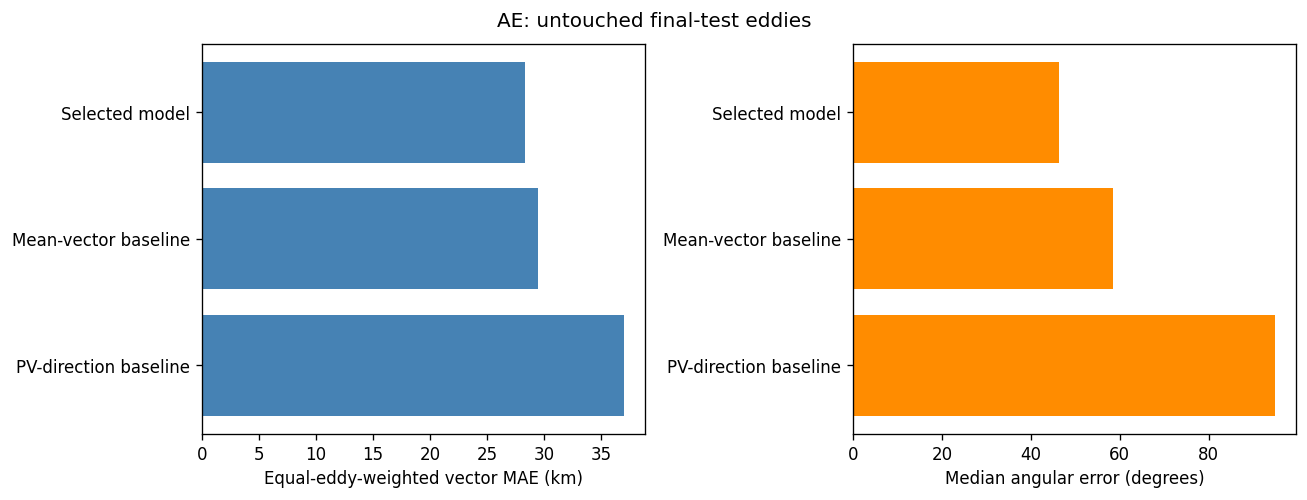

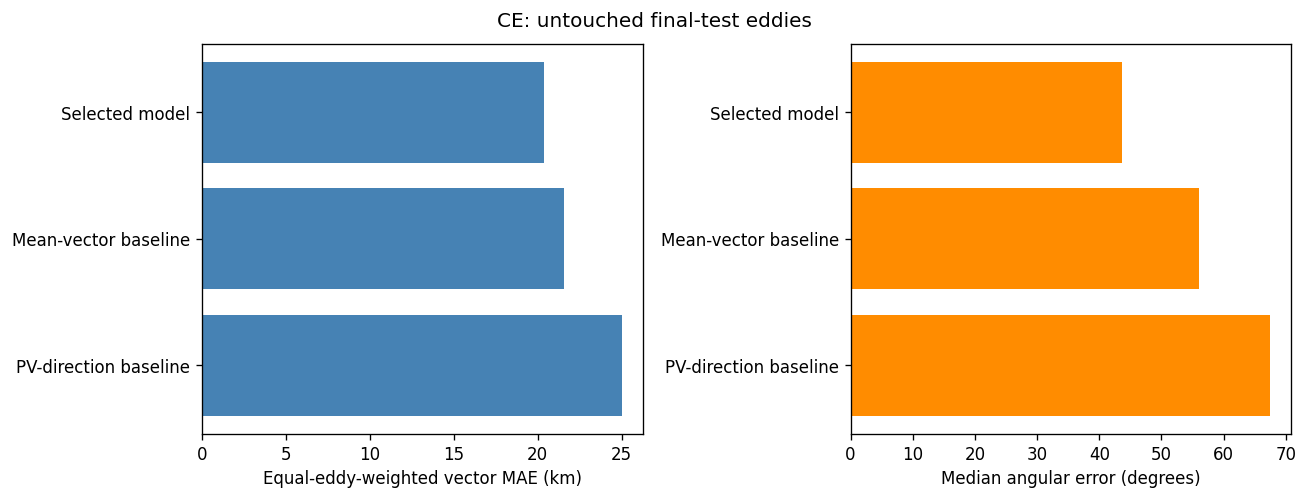

In [9]:
final_results = {}
for cyc, split in splits.items():
    fitted, prediction, scores, predictions = ml.fit_selected_and_test(
        selected[cyc], split, features=chosen_features[cyc], random_state=RANDOM_STATE
    )
    final_results[cyc] = {
        "fitted": fitted, "prediction": prediction,
        "scores": scores, "predictions": predictions,
    }
    print(f"{cyc}: {selected[cyc]}")
    print(f"Features: {chosen_features[cyc]}")
    display(scores.round(3))
    fig, axes = ml.plot_model_comparison(scores)
    fig.suptitle(f"{cyc}: untouched final-test eddies", y=1.03)

,rows,median_angular_error_deg,within_30deg_fraction
minimum_tilt_km,,,
0,7528,46.237,0.368
5,6857,43.281,0.386
10,5700,40.945,0.403
20,3460,35.978,0.439


,rows,median_angular_error_deg,within_30deg_fraction
minimum_tilt_km,,,
0,8491,43.705,0.372
5,7565,41.369,0.386
10,5824,38.967,0.405
20,2954,35.642,0.435


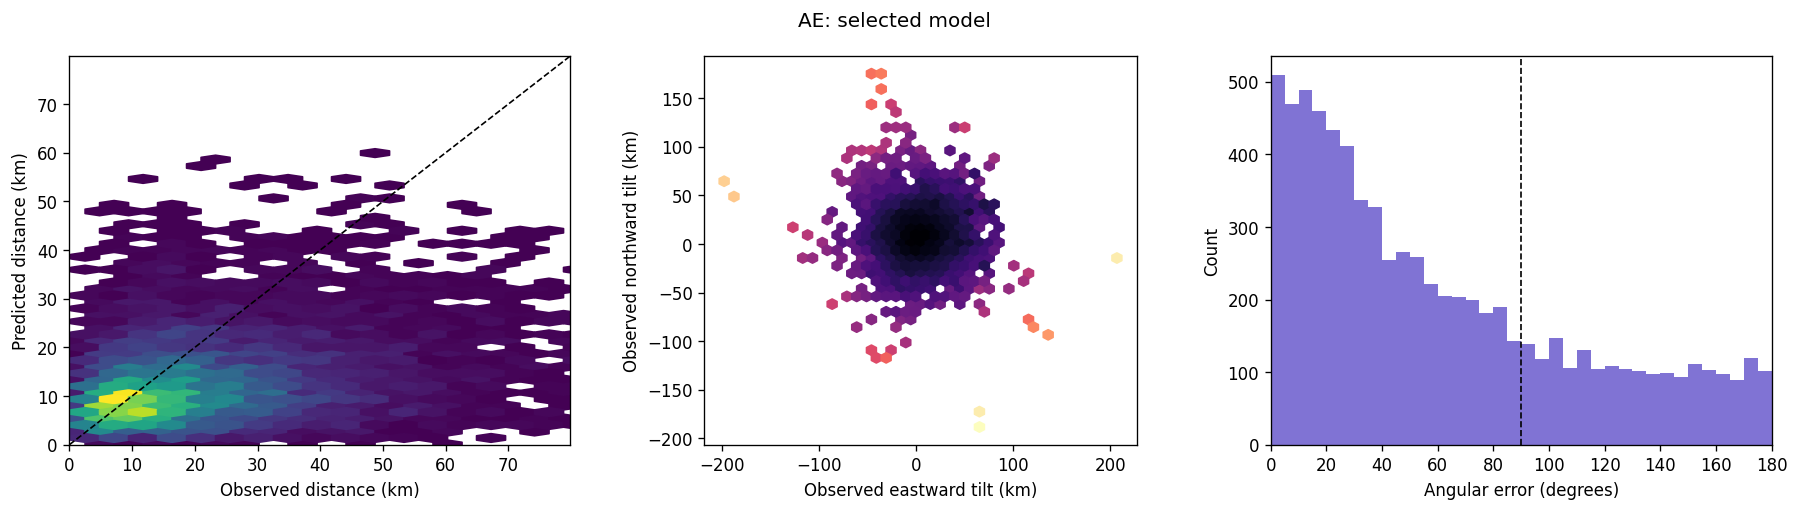

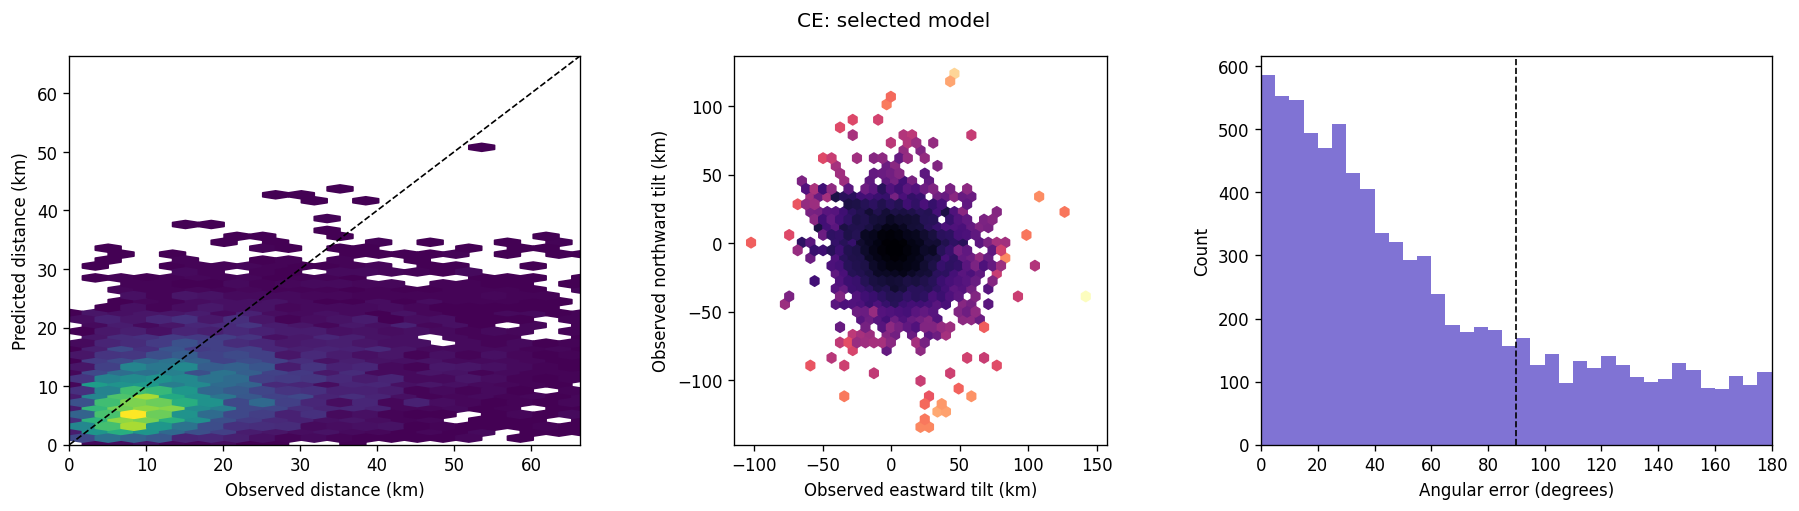

In [10]:
for cyc, result in final_results.items():
    ml.plot_prediction_diagnostics(result["prediction"], title=f"{cyc}: selected model")
    display(ml.direction_performance_by_tilt(
        result["prediction"], thresholds=(0, 5, 10, 20)
    ).round(3))

## 8. Final-test permutation importance

Importance measures the increase in equal-eddy-weighted vector MAE after shuffling one selected feature in the untouched test set. It measures predictive reliance, not causality.

,feature,importance_mean,importance_std
7,prop_north_km_day,0.9201,0.1121
0,beta,0.9184,0.0713
6,prop_east_km_day,0.8270,0.0690
13,PV_grad_east,0.3841,0.0544
8,ellipse_major_cos2,0.3015,0.0511
12,PV_grad_mag,0.2905,0.0464
1,h,0.2617,0.0568
9,ellipse_major_sin2,0.2446,0.0838
14,PV_grad_north,0.1500,0.0498
2,Omega,0.0934,0.0384


,feature,importance_mean,importance_std
0,beta,0.9962,0.0555
6,prop_east_km_day,0.7893,0.0548
7,prop_north_km_day,0.7501,0.0613
13,PV_grad_east,0.7016,0.0488
14,PV_grad_north,0.5035,0.0429
1,h,0.3728,0.0392
12,PV_grad_mag,0.3077,0.0337
2,Omega,0.2433,0.0404
3,Rc,0.1623,0.0456
5,norm_time,0.1418,0.0304


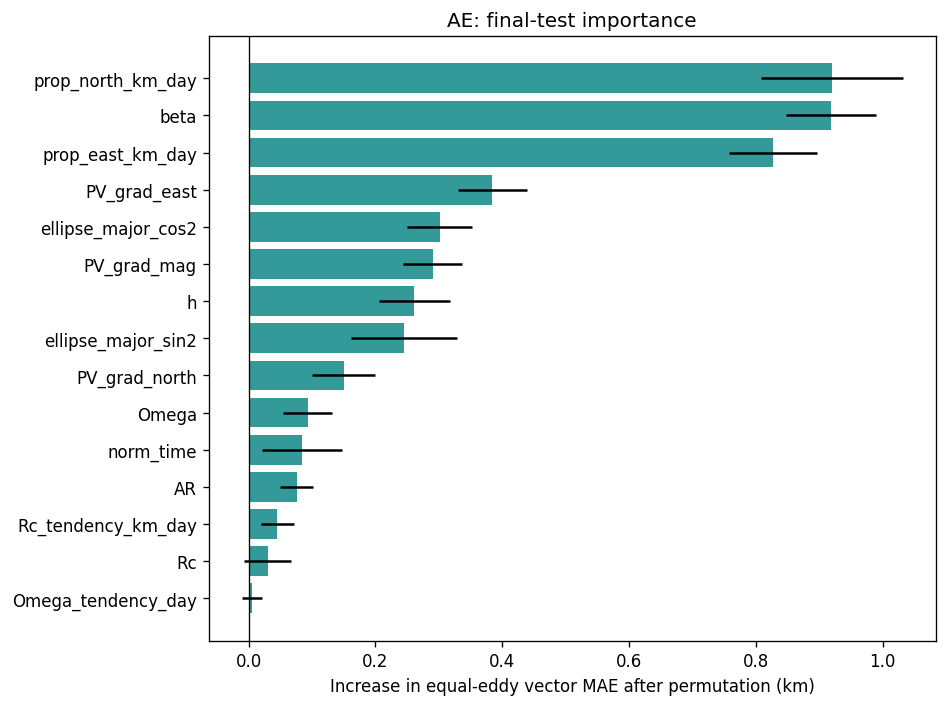

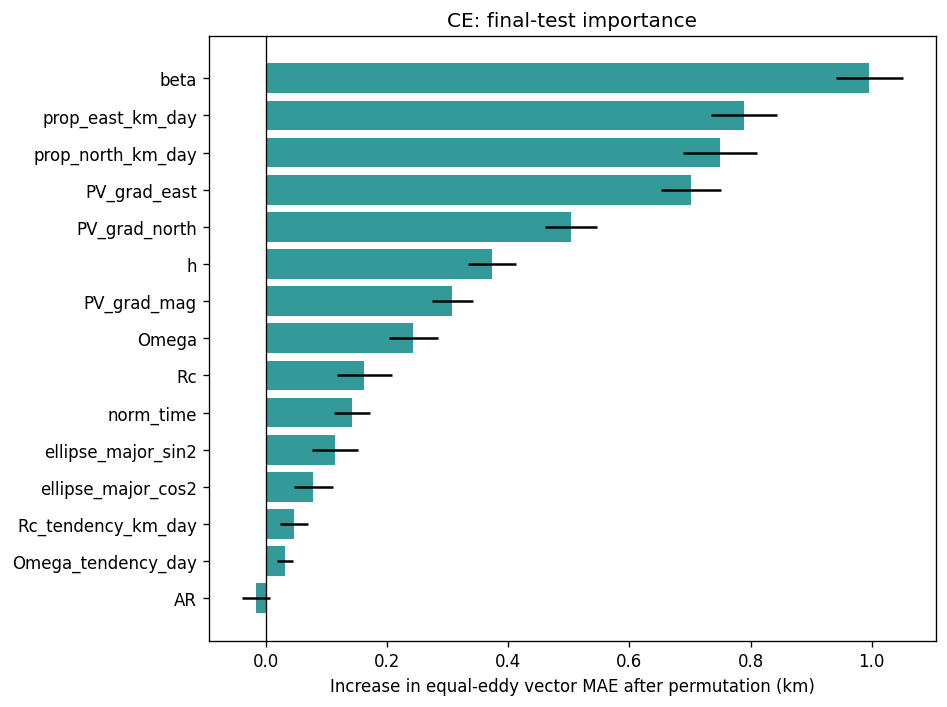

In [11]:
importance_results = {}
for cyc, result in final_results.items():
    importance = ml.raw_feature_permutation_importance(
        result["fitted"], splits[cyc].test, selected[cyc],
        features=chosen_features[cyc], n_repeats=10, random_state=RANDOM_STATE,
    )
    importance_results[cyc] = importance
    display(importance.round(4))
    ml.plot_permutation_importance(importance, title=f"{cyc}: final-test importance")

## 9. Interpretation checklist

A polarity-specific ML approach is supported only if the selected model improves consistently over both fold-specific baselines during tuning, repeated training-only validation, and the untouched final test. Prioritise equal-eddy-weighted vector MAE; then inspect distance and thresholded angular skill.

Report for AE and CE separately:

- the selected model family, hyperparameters, target formulation, and feature set;
- training-CV and repeated-split performance relative to both baselines;
- untouched test performance, including equal-eddy-weighted metrics;
- whether the PV-relative target improves direction;
- whether PV magnitude adds information beyond its components;
- whether the propagation, ellipse, `Rc` tendency, and `Omega` tendency features improve CV;
- performance for larger tilts, where direction is better defined.

Do not interpret permutation importance as causal evidence. A negative result remains scientifically useful: it indicates that the tested surface signatures do not constrain instantaneous 859 m tilt sufficiently for unseen eddies.